In [1]:
#Week 5 Critical Thinking - Image Dataset Augmentation for a CNN Classifier
#John Wensink
#CSC525 Principles of Machine Learning
#Colorado State University - Global Campus
#Dr. Dong Nguyen
#June 15, 2025



In [2]:
#In this first cell we'll import the 'Path' module and set our dataset path to the working directory's data subfolder.
from pathlib import Path
#(Python Documentation, n.d. -a)

dataset_path = Path("data/W5CT_BirdSpeciesData_Original/images")
#(Ailurophile, 2020)

#In my python workflows to date, I've always relied on the 'os' module for tasks like path construction, directory traversal, and filename validation. There is another way thouh. Python's 'pathlib' module offers a more modern, object-oriented approach to working with filesystem paths. We'll give it a try today to learn a new module. The dataset is Caltech's 'Birds-200-2011' contains aproximately 12,000 images of 200 different species of birds, each organized into its own folder. All images are in .jpg format, this makes them lightweight and compatible with the image processing libraries we're planning on using today (OpenCV, Pillow, TorchVision.) Images are stored in RGB with 3 true-color chanels. The image dimensions vary in size and there is no consistent resolution. The folder contains portrait and landscape format images with a variety of backgrounds and color conditions. As such this is an ideal dataset to demonstrate normalization techniques for data augmentation or generalization.

In [14]:
#Subfolder directory structure
import random  #(GeeksforGeeks, 2025)

species_subfolders = list(dataset_path.iterdir())

preview_folders = random.sample(species_subfolders, 5)

for folder in preview_folders:
    jpg_images = list(folder.glob("*.jpg"))
    count = len(jpg_images)
    name_parts = folder.name.split(".")
    print(f"Preview folder {name_parts[0]} {name_parts[1]} contains {count} .jpg image files")


#Before applying any transformations, we'll want to display and verify a random sample of image files from our dataset to ensure the format and structure are what we're expecting. Let's make sure we've got the working directory's /data/W5CT_BirdSpeciesData_Original subfolder structure correctly mapped first

Preview folder 155 Warbling_Vireo contains 60 .jpg image files
Preview folder 134 Cape_Glossy_Starling contains 60 .jpg image files
Preview folder 038 Great_Crested_Flycatcher contains 60 .jpg image files
Preview folder 022 Chuck_will_Widow contains 56 .jpg image files
Preview folder 199 Winter_Wren contains 60 .jpg image files


Showing images from: 155.Warbling_Vireo


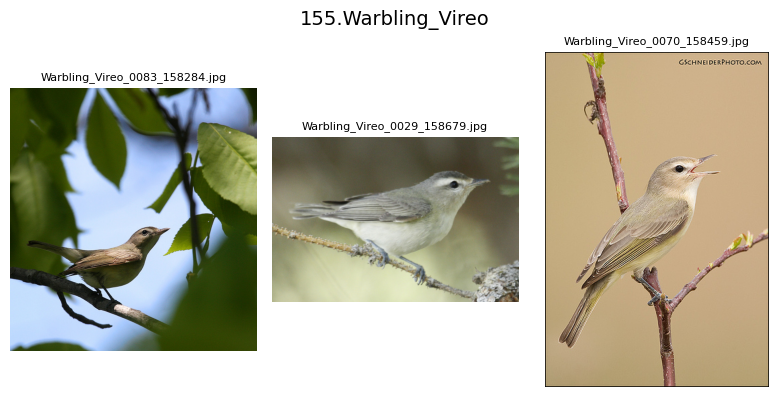

Showing images from: 134.Cape_Glossy_Starling


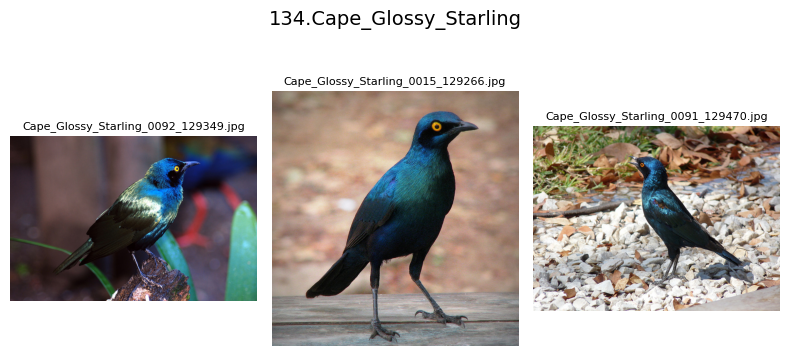

Showing images from: 038.Great_Crested_Flycatcher


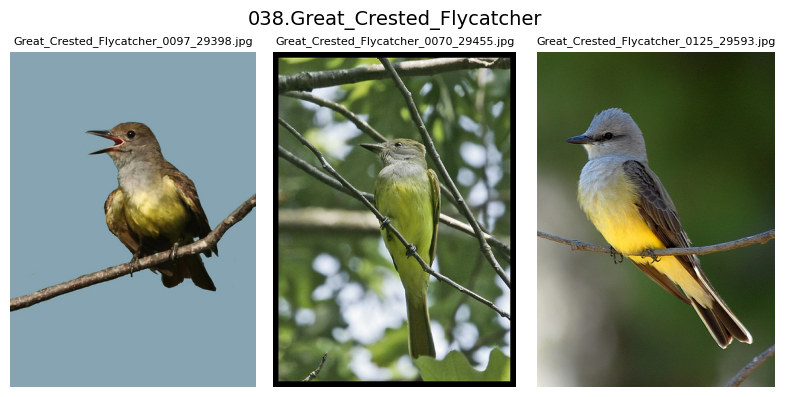

Showing images from: 022.Chuck_will_Widow


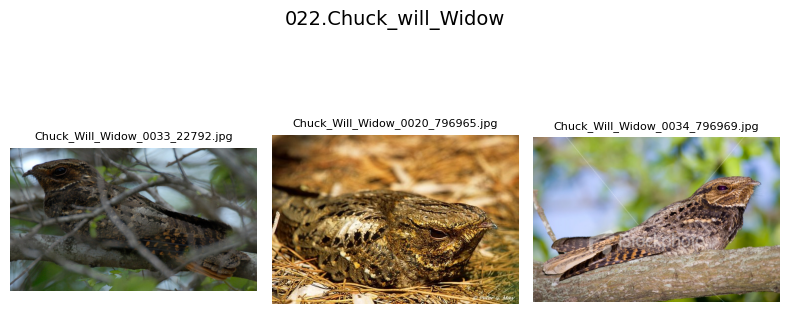

Showing images from: 199.Winter_Wren


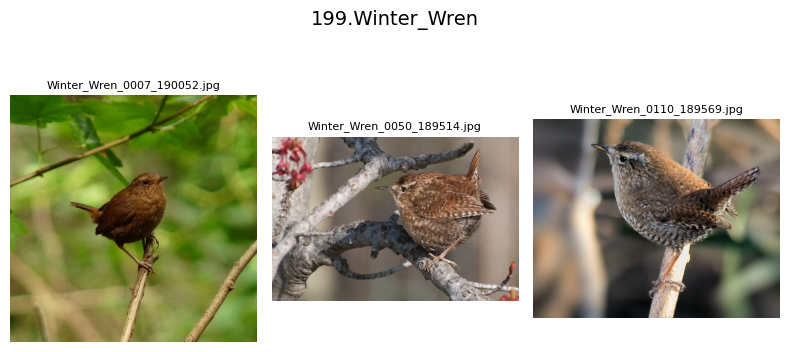

In [15]:
#Now that we have a random sample of subfolders selected, we're ready to display some images out of those subfolders to get a visual idea of what kind of data we're looking at. We'll use Pillow for opening and handling the image files, and matplotlib to display them in a grid layout.
from PIL import Image  #(Gruppetta, 2025)
import matplotlib.pyplot as plt  #(Hunter et al., 2025)

#We'll iterate over each of the previously selected preview_folders. We are wanting to display 2 random images from the randomly selected folders of our dataset
for folder in preview_folders:
    #We'll declare the variable preview_images here to gather all the image files from the current folder. Since we know our dataset consists only of .jpg images, calling .glob("*.jpg"), we can search through that folder for all files ending in .jpg and store them as a list of the images' paths
    preview_images = list(folder.glob("*.jpg"))
    #Randomly select two images from the list preview_images. Each time the code runs, we'll get a different pair of images from the current folder
    sample_images = random.sample(preview_images, 3)

    #Title of our PyPlot showing what images are being displayed
    print(f"Showing images from: {folder.name}")

    #I used an LLM (Grimoire, 2025) to set up my PyPlot, and edited the parameters myself to give a nice 1x3 grid to show random images from our preview_folders
    fig, axes = plt.subplots(1, 3, figsize=(8, 4))
    fig.suptitle(folder.name, fontsize=14)

    #Loop to display each image in sample_images on its own subplot axis. The 'zip' function matches each subplot axis with one image file path (image_path)
    for ax, image_path in zip(axes, sample_images):
        image = Image.open(image_path)
        ax.imshow(image)
        ax.set_title(image_path.name, fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

#With a visual preview of random images from our dataset, we can see that the images differ substantially in size, lighting, orientation, and background. To address these inconsistencies and normalize our data, there are I few preprocessing steps I would consider, keeping in mind that the ultimate goal for this data is to build a classifier. First, I would resize all images to a consistent shape, which ensures that the input to the model is uniform and compatible with the ML architecture that the data will eventually be used for. It will also be important to normalize pixel values across all images to put the data on a similar scale. This is a fairly robust dataset, but applying some augmentation techniques like random brightness, contrast adjustments, flipping, and rotations can help the model to generalize on unseen real-world data. Additionally, cropping and zooming can simulate different perspectives and further increase the diversity of the dataset. Let's take these steps one at a time to create a more balanced and generalized dataset that will help our classifier perform better when faced with new and varied images.

In [16]:
#Let's create another subfolder in our working directory's data folder. We'll call it W5CT_BirdSpeciesData_Resized. The first step is to transfer all the image subfolders from W5CT_BirdSpeciesData_Original. We can use the Python module shutil to copy the jpg files while preserving their metadata and folder structure while building the augmented datasey

import shutil #(Python Documentation, n.d. -b)

#Source and destination paths
source = Path("data/W5CT_BirdSpeciesData_Original/images")
destination = Path("data/W5CT_BirdSpeciesData_Resized/images")

#Iterate through all jpg files in the source directory and its subdirectories using the rglob method (Hjelle, 2025) of Python's pathlib.Path class. This works as rglob(pattern) searches recursively through the directory tree, matching file and directory names according to the specified glob-style pattern. Unlike glob(), rglob() returns a generator of path objects making it memory efficient for large file trees. Pretty cool.
for file in source.rglob("*.jpg"):
    relative_path = file.relative_to(source)
    destination_file = destination / relative_path
    destination_file.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(file, destination_file)


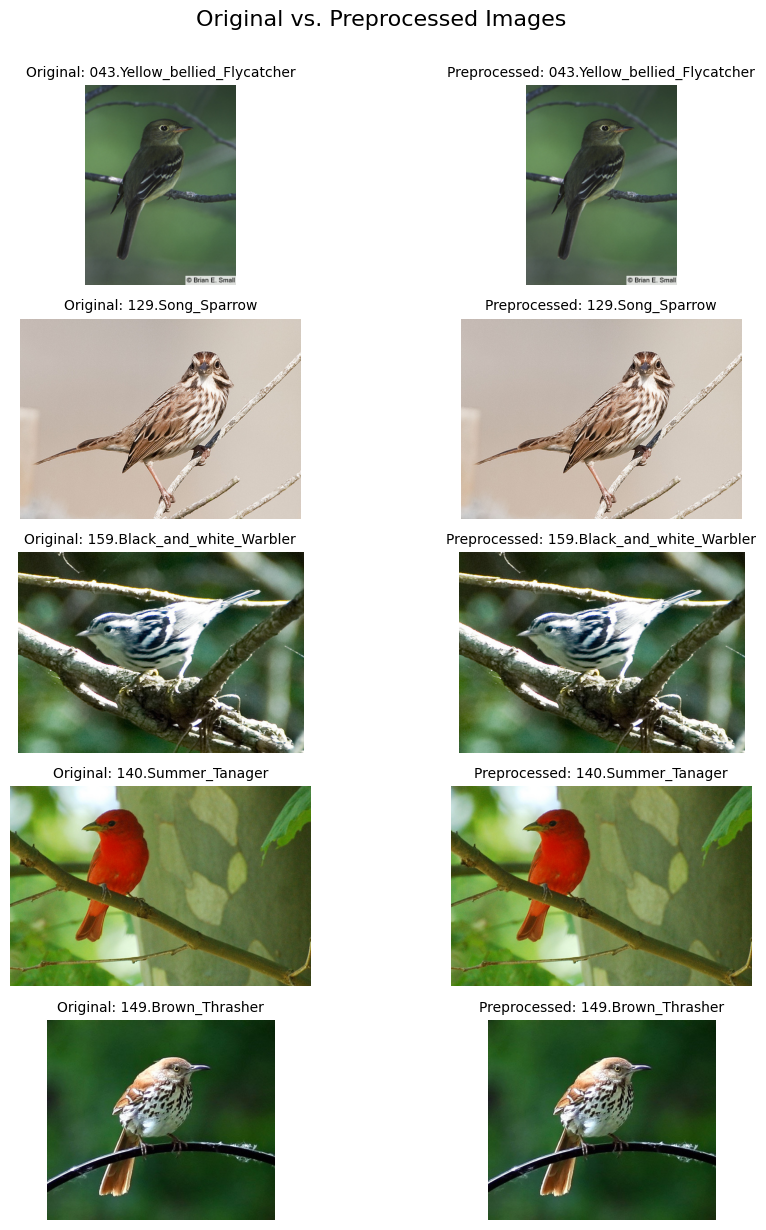

In [17]:
#In this cell we're going to define a reusable compare() function so that we can easily visualize the preprocessing changes we're going to apply at every step. We'll make a PyPlot to randomly select a set number of species folders and sample one image from each, and then display them. I got stuck here a bit and used the LLM (Grimoire, 2025) to help me out with the path logic

#We'll define compare() with the default of 1 set of images to be compared, if we set it up this way we can change the number of comparisons just by setting the argument as the x desired comparison display
def compare(sample_count=1):
    #Paths for the comparisons
    original_root = Path("data/W5CT_BirdSpeciesData_Original/images")
    augmented_root = Path("data/W5CT_BirdSpeciesData_Resized/images")

    #Same logic as above with our preview_folders
    species_folders = list(original_root.iterdir())
    random_sample = random.sample(species_folders, sample_count)

    #I used the LLM (Grimoire, 2025) to set up a clean PyPlot for me again)
    fig, axes = plt.subplots(nrows=sample_count, ncols=2, figsize=(10, 2.5 * sample_count))
    fig.suptitle("Original vs. Augmented Images", fontsize=16)

    #Iterate through each folder in the list of randomly sampled species directories using enumerate() with random_sample as the argument. This provides both the loop index i, as well as the folder path object for each iteration
    for i, folder in enumerate(random_sample):

        #Declare the variable species_name and assign the value of folder.name, a string representing the folder's final path segment (i.e. 116 Chipping_Sparrow)
        species_name = folder.name

        #Declare the variable original_image and assign to it a list of all jpg files found directly inside the current folder by using list(folder.glob("*.jpg")). This expression will search only the current directory level (not subdirectories) and return a list of path objects representing each matched file
        original_images = list(folder.glob("*.jpg"))

        #Use the conditional 'if not original_images' to check whether the original_images list is empty. If it is (no jpg files found in the current folder), the continue statement is executed and the rest of the loop is skipped for that iteration and the loop moves on to the next folder in the list. This prevents errors that would occur if the code tried to process or display a nonexistant image
        if not original_images:
            continue

        #Declare the variable selected_file and assign it a single image at random from the original_images list. The random.choice() function ensures that the selected file varies each time the function is run to support randomized inspection of our data
        selected_file = random.choice(original_images)

        #Compute the path of the selected image relative to the root of the original dataset. This removes the leading portion of the file path, leaving only the subfolder and filename (i.e. 116.Chirping_Sparrow/image_0045.jpg)
        relative_path = selected_file.relative_to(original_root)

        #Construct the full path to the corresponding image in the augmented dataset by appending the previously computed relative_path to the base directory augmented_root. This ensures that the program referecnces the correct augmented version of the same original image
        augmented_file = augmented_root / relative_path

        #Open the selected image from the original dataset
        original_image = Image.open(selected_file)
        #Open the selected image from the augmented dataset
        augmented_image = Image.open(augmented_file)

        #PyPlot constructor, for each row 'i' in the subplot grid, display the original image in the left column and the augmented image in the right column. Assign a label to each sublpot, and we have no real need to display the axes here.
        axes[i, 0].imshow(original_image)
        axes[i, 0].set_title(f"Original: {species_name}", fontsize=10)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(augmented_image)
        axes[i, 1].set_title(f"Preprocessed: {species_name}", fontsize=10)
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()


#Let's take it for a spin. Without any preprocessing we should show identical images for original and augmented, but in future cells, we can see how our preprocessing is working without having to copy/paste that monstrosity of PyPlot/PathLib code. Looks like it's working as intended. So satisfying!
compare(5)

In [18]:
#Preprocessing step #1 - Resizing

#Since our dataset contains both square and rectangular images, our resizing strategy will need to balance uniformity with minimizing distortion (to preserve shape and features.) We have three main options each with their own trade-offs. We could:
#1:) Go with direct resizing (224x224) for all images. Pros: Easy, fast, and this is the required size for a lot of transfer learning CNNs like ResNet/ImageNet. Cons: Will distort images that aren't square already.
#2:) Resize while preserving aspect ratio. By resizing the image so that the longer size matches a target size, and then pads the shorter side with a filler color we could create a square image. Pros: Maintains original geometry and avoids distortion and leaves us with our desired 224x224 output. Cons: Will require more preprocessing and introduce artificial borders that our classifier might overfit to. We could potentially mitigate the risk of overfitting by randomizing the padding color slightly within a neutral range, we might apply a crop or jitter as a secondary augmentation, or we could even pre-train with padded images
#3:) Reszie with a center crop by resizing the shorter side to a target length, then crop the center square. Pros: would preserve resolution and avoid distortion Cons: Likely to cut off meaningful parts of the bird as most preview images appear to have the bird centered. For this dataset, center cropping is not a realistic solution

#So we're left with options #1 and #2. I think option #2 is probably the most sophisticated solution and should theoretically work as long as we are careful to ensure that the padding does not introduce bias into the model's learning process. Option #2 gives us the advantage of maintaining the bird's original proportion while still standardizing to the 224x224 format expected by most CNNs. To help the classifier learn to ignore these padding bars, the goal will be to make the padding uninformative, non-repetitive, and ideally invisible to the model during training. Adding dropout layers or weight decay could work to discourage the model from overfitting on these regions, and attention visualization tools like Grad-CAM might be applied post-training to inspect whether the model is focusing on birds or padding, if it shows the model is training on padding we might need to revise our resizing strategy (Selvaraju et al., 2019.)

from PIL import ImageOps #(Pillow Documentation, 2011)

TARGET_SIZE = 224

#We'll define a function called resize_with_padding here with the arguments for
#-image - this is the required input, it's expected to be a PIL.image object i.e. an image already opened using Image.open()
#-target_size=TARGET_SIZE - our desired 224x224 output
def resize(image, target_size=TARGET_SIZE):

    #Generate a single random integer between 100 and 150 to select a random medium gray color for our padding bar
    random_gray = random.randint(100, 150)

    #We'll assign our RGB color tuple as a result of our color randomizer above
    fill_color = (random_gray, random_gray, random_gray)

    #Resize the image in place so that it fits within our 224x224 box while preserving the aspect ratio.
    image.thumbnail((target_size, target_size),

    #The LANCZOS filter is a downsampling method that uses a sinc function to interpolate pixel values when reducing image sizes. Known for producing smoother and more accurate results than alternatives like NEAREST, BILINEAR, or BICUBIC by minimizing aliasing artifacts and preserving fine details in images with complex textures (Karpinsky, 2022)
    Image.Resampling.LANCZOS)

    #Declare the variable padded_image and assign the result of Pillow's ImageOps.pad(), which takes arguments for:
    #-image - the input image
    #-(target_size, target_size) - which we've already assigned to TARGET_SIZE = 224
    #-color=fill_color - which we've already assigned as our randint for a random gray
    padded_image = ImageOps.pad(image, (target_size, target_size), color=fill_color)

    #If all goes well, we should return the resized and padded image.
    return padded_image

In [19]:
#We've defined resize() above and we'll execute it in a new cell for any inevitable error isolation that will be required. If something fails during I/O or processing, we can just re-run this cell without having to redefine the function

#We'll need to declare augmented_root globally here because previously, it was only defined in the compare() function. Using Path() gives us the ability to use methods like .rglob("*.jpg") for recursive file listing
augmented_root = Path("data/W5CT_BirdSpeciesData_Resized/images")

#Here's the main for loop that will iterate through every jpg image found within our augmented_root directory, where we're saving our preprocessed images to compare them to our original images. For each file, the image is opened using Pillow's Image.open() and converted to RGB to ensure a consistent coloring scheme regardless of the image's original color format. The opened image is then passed to our resize() function, and then saved back to its original file path. This is the loop that will standardize all 11,788 images (1.19GB) so it might take a few seconds to run, but still suitable for CPU processing
for file in augmented_root.rglob("*.jpg"):
    image = Image.open(file).convert("RGB")
    resized = resize(image)
    resized.save(file)

#The resizing operation appears to have executed without error in about 15 seconds, let's run compare() in its own cell below so that we won't have to run this computationally expensive cell every time we want to see our comparison PyPlot

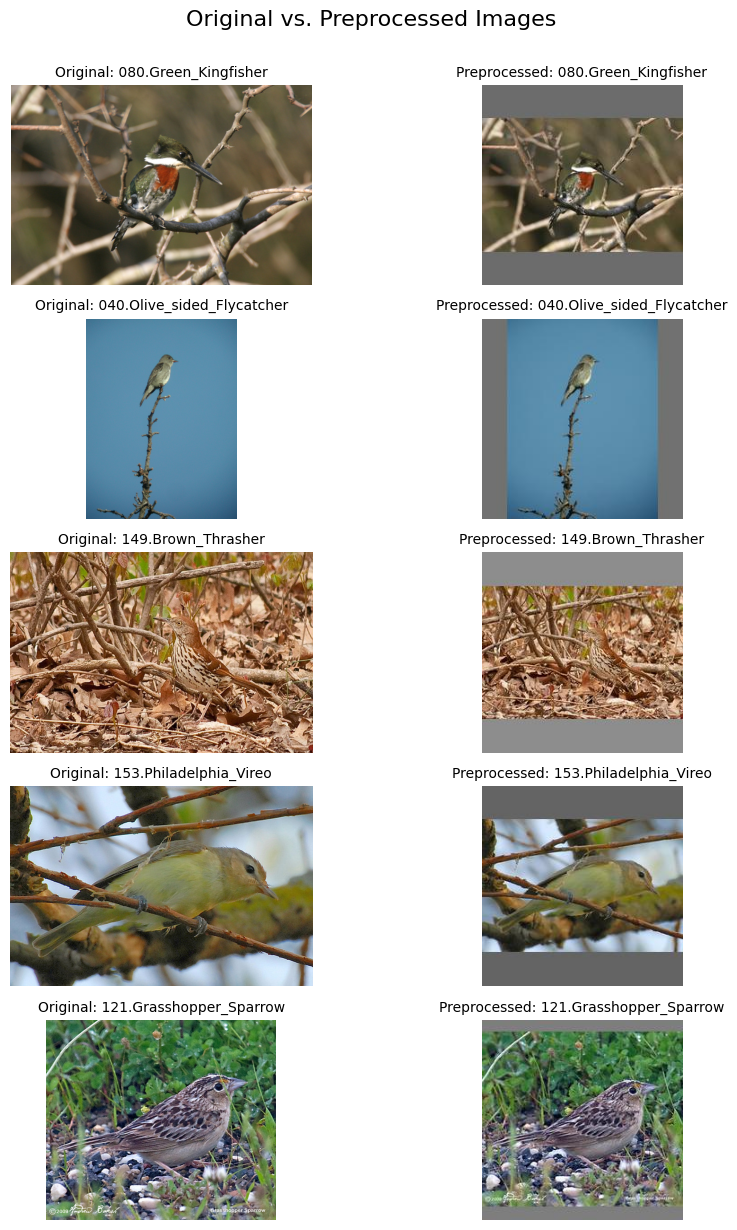

In [20]:
#We'll run our compare(n) function now and expect a PyPlot of our image data before and after preprocessing to 224x224 padded squares
compare(5)

#That turned out even better than I thought it would, in fact I'm a bit suspicious that the images might not be truly 224x224 due to the sharpness/resolution being preserved so well compared with the original images. We can test that out in the cell below

In [21]:
resized = resize(image)
print(resized.size)

#Sure enough, our images were output to the desired size of 224x224. Pillow's LANCZOS filter seems to have done an excellent job of preserving image clarity and minimized distortion. When visualized in Matplotlib, the transformed images are rendering correctly without stretching or issues with the aspect ratio confirming that the padding and resampling pipeline is functioning as expected

(224, 224)


In [22]:
#Preprocessing step #2: Dataset Augmentation

#Now that our images have been resized to a uniform 224x224 resolution that preserves aspect ratio, the next logical step is to introduce some data augmentation. We have countless options to explore in this arena (PyTorch Documentation, n.d. -a), but the three that are most likely to be useful are:

#1: Geometric transformations like rotation, translation, and scaling. These can improve invariance to viewpoint and positioning. However, I've noticed in our dataset that many bird species have specific postures or orientations that could be useful in classification, and transforming these might introduce misleading artificial features (Stavshevsky, 2023). For example, rotating an image could present the bird in an anatomically implausible pose, or translation might push the subject out of frame. These types of augmentation techniques are generally more useful when class semantics are preserved under viewpoint shifts, which might not apply uniformly across our different class categories

#2: Random cropping is another commonly used augmentation technique that can help to augment the model become more resiliant to partial occlusions and varying object locations. This seems like it would be quite useful in our dataset, as many of our bird images are partially occluded by branches, leaves, or shadows. From the preview thumbnails I have seen, most of the birds are relatively centered within the frame. Applying random crops could risk cutting off important features like beaks or wings, which are very important for distinguishing between bird species. This could introduce noise into the training process or degrade model accuracy by presenting incomplete or misleading feature information (Nelson, 2020.) Although random cropping might introduce some benefits, the tradeoff in this case doesn't appear to be worthwhile given the composition of the dataset

#3: Color perturbations using the ColorJitter transform. This transform introduces controlled randomness to brightness, contrast, saturation, and hue (PyTorch Documentation, n.d. -d). Since bird photos are often taken in uncontrolled environments (i.e. varying lighting, time of day, and shadows), this approach can improve invariance to lighting conditions without altering shape or geometry of the birds' desired features. Although many species of birds are best classified by their coloration, this can vary substantially throughout the birds maturation from juvenile to adult, and it might be counterproductive for the model if it were overfitting on specific lighting-dependent color patterns. By applying ColorJitter, the model might generalize better across natural lighting variations while still learning to focus on more stable cues like feather patterns, beak shapes, body structures, or postures.

#Using ColorJitter transform seems like the best augmentation strategy for our data and our model, because it enhances our dataset in a way that reflects the real-world variability our model is likely to encounter during inference on unseen data. Unlike geometric or cropping-based augmentations, ColorJitter does not introduce spatial distortion or occlusion artifacts. It targets one of the most common and least controllable sources of variation in wildlife photography, lighting. Being able to tune the amount of jitter for each individual characteristic (brightness, contrast, saturation, and hue), we can avoid a 'one-size-fits-all' approach to data augmentation and custom tailor an augmentation strategy that is uniquly applicable to our model and dataset.

In [23]:
#We've decided to go with ColorJitter, which is a photometric augmentation technique available from the torchvision library. The augmentation is applied to every image in our resized dataset. Each output image will be saved with the same relative directory structure into a new destination folder, ensuring that our preprocessing data stays organized and traceable. This enusres that improvements/degradations to the model can be measured and rolled back if needed. By storing augmented image data in a separate folder, we can combine it with our resized dataset, use it by itself, or decide not to use it at all since our dataset was pretty sizable to begin with.
from torchvision import transforms

#ColorJitter is relatively straightforward, a torchvision function with parameters for brightness, contrast, saturation, and hue. Settings here will represent the absolute value +- that we will allow the transformation to perturb each respective attribute when the function is applied. For example brightness=0.3 will allow for random adjustments from 0.7% - 1.3% of the original value, mimicing the variability found in real-world lighting conditions.
color_jitter = transforms.ColorJitter(
    brightness=0.3, #Relatively large brightness to allow for day/night/shadow/overcast lighting conditions
    contrast=0.3, #Same idea for contrast, lots of real world variability in lighting dynamics from bright sunlight to deep shadow
    saturation=0.1, #Relatively small adjustments in saturation as coloration is often a key identifying feature for birds
    hue=0.05 #Hue set even smaller because even slight sifts in hue can dramatically change percieved coloration
)

#Same idea as above, we're writing new jpg files into a new folder for Jittered
source = Path("data/W5CT_BirdSpeciesData_Resized/images")
destination = Path("data/W5CT_BirdSpeciesData_Jittered/images")

for file in source.rglob("*.jpg"):
    relative_path = file.relative_to(source)
    destination_file = destination / relative_path
    destination_file.parent.mkdir(parents=True, exist_ok=True)

    image = Image.open(file).convert("RGB")
    jittered_image = color_jitter(image)
    jittered_image.save(destination_file)


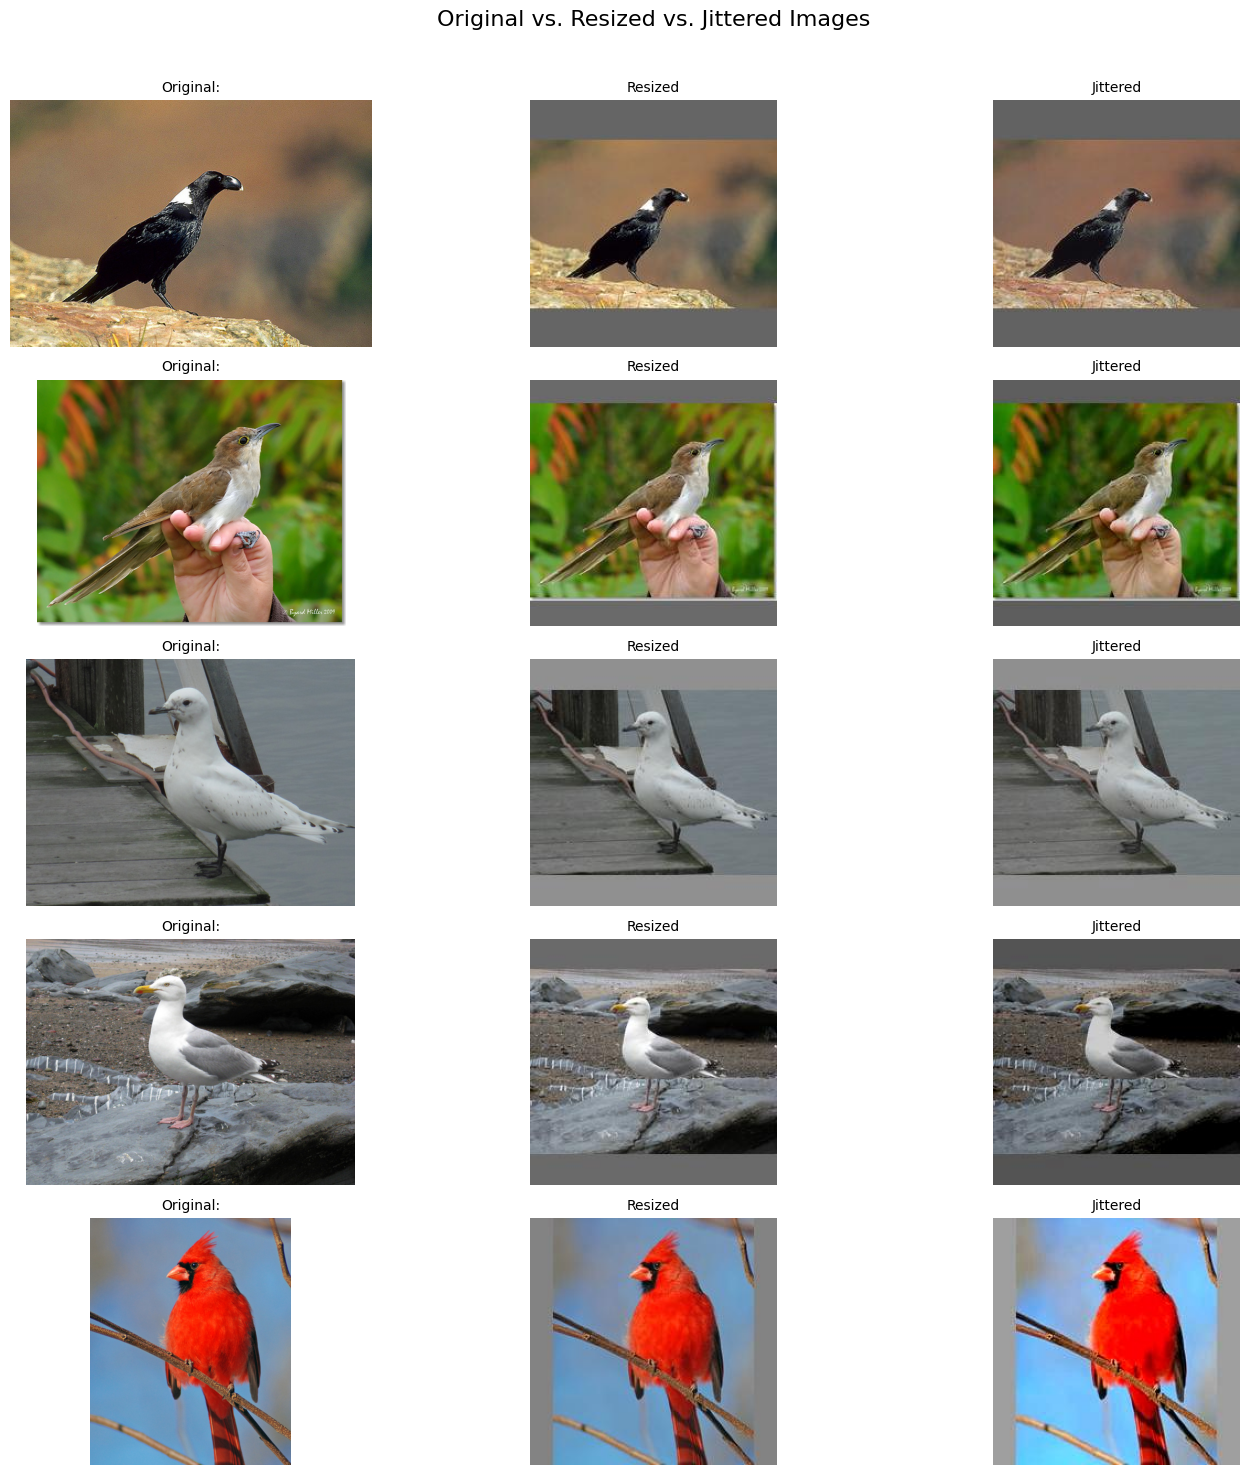

In [46]:
#Now we can define a function compare2() that can compare our original images, resized images, and now jittered images. Following the same logic as compare()

def compare2(sample_count=1):
    original_root = Path("data/W5CT_BirdSpeciesData_Original/images")
    resized_root = Path("data/W5CT_BirdSpeciesData_Resized/images")
    jittered_root = Path("data/W5CT_BirdSpeciesData_Jittered/images")

    species_folders = list(original_root.iterdir())
    random_sample = random.sample(species_folders, sample_count)

    fig, axes = plt.subplots(nrows=sample_count, ncols=3, figsize=(15, 3 * sample_count))
    fig.suptitle("Original vs. Resized vs. Jittered Images", fontsize=16)

    for i, folder in enumerate(random_sample):
        species_name = folder.name
        original_images = list(folder.glob("*.jpg"))
        if not original_images:
            continue
        selected_file = random.choice(original_images)
        relative_path = selected_file.relative_to(original_root)

        resized_file = resized_root / relative_path
        jittered_file = jittered_root / relative_path

        original_image = Image.open(selected_file)
        resized_image = Image.open(resized_file)
        jittered_image = Image.open(jittered_file)

        axes[i, 0].imshow(original_image)
        axes[i, 0].set_title(f"Original:", fontsize=10)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(resized_image)
        axes[i, 1].set_title("Resized", fontsize=10)
        axes[i, 1].axis("off")

        axes[i, 2].imshow(jittered_image)
        axes[i, 2].set_title("Jittered", fontsize=10)
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

compare2(5)

In [47]:
#Preprocessing step #3 - Normalizing the pixel values (Kashyap, 2024)

#Since our goal is to build a classifier CNN that uses reinforcement learning from ResNet/ImageNet, and our dataset consists of high-quality RGB bird photographs taken under varied lighting conditions and with inconsistent backgrounds, we need to consider both model expectations and dataset characteristics when choosing a normalization strategy. We have two realistic options to choose from. We could:
#1:) Use Min-Max scaling (i.e. to [0, 1]) or x_scaled = x / 255. Pros are that it's simple and fast. This method will preserve the relative structure and contrast of the input images, which is important in a fine-grained classification task like this. It helps standardize the input magnitude across the dataset without reducing the influence of the subtle pixel-level cues such as plumage color or shadow detail. This approach is well suited to datasets with varied exposure and lighting like ours and offers a flexible starting point for custom CNNs. Cons are that while numerical stability is improved, the data is not going to be zero-centered. For pre-trained models that are typically trained on zero-centered inputs, it might lead to issues with or slower convergence, or less effective weight adaptation unless further normalization is applied later in the pipeline

#2:) Use mean-standard normalization (i.e. (x - μ) / σ) AKA zero-centering, normalizing to [-1, 1] This approach has the pro that it aligns with the normalization scheme used during ResNet's original ImageNet training in PyTorch (PyTorch Documentation, n.d. -c) which expects pixel values first scaled to [0, 1], and then standardized using per-channel ImageNet statistics (μ = [0.485, 0.456, 0.406], σ = [0.229, 0.224, 0.225].) This could make our CNN more compatible with eventual augmentation through transfer learning and could potentially accelerate convergence. The big con however is that these transformed values are not human-readable, making visualization and debugging less intuitive.

#Since our model's eventual goal is to use transfer learning wit a pretrained ResNet model from TorchVision, I think mean-standard normalization is probably the correct choice here. Since we're not training a CNN completely from scratch, using ImageNet's statistics makes a lot of sense. Those were learned by going through a LOT of images and computing channel-wise means and deviations on the RGB data distributions. By aligning our inputs to that same distribution, we'll be putting our images into a format that the pretrained layers are already tuned to understand. The downside of not being human-readable shouldn't be too much of a concern, as there are tools available like Grad-CAM and TensorBoard (which can now be used with PyTorch ,neat) to help us visualize our normalization results (PyTorch Documentation, n.d. -b) Since I haven't had an opportunity to learn about TensorBoard, this will be a good opportunity to become familliar with it and explore how it can support model interpretability. We'll be saving the pixel-normalized images as tensors at this point, and visualizing them using TensorBoard, and saving screenshots of a few images

In [48]:
#Pixel normalization function
from torchvision import transforms
import torch

#Since our resizing function returned PIL images which are currently stored as 8-bit RGB images, we'll need transforms.ToTensor() to convert the image into a float tensor (C, H, W) to initially scale our pixel values from [0, 255] to [0.0 to 1.0] (min-max scaling) before our intended mean-standard normalization
pil_to_tensor = transforms.ToTensor()

#Now that our tensor is [0, 1] normalized, we can apply ImageNet's channel-wise mean and standard deviation normalization values to transform our pixel values into the zero-centered distribution expected by pretrained ResNet models in TorchVision
mean_standard_tensorized = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

tensor_image = pil_to_tensor(image)
normalized_image = mean_standard_tensorized(tensor_image)

#We've now normalized and zero-centered our pixel values using mean-standard normalization. From here we will either need to view our comparisons in tensorboard, or de-normalize the images which kind of misses the point and undermines our efforts so far. I'm excited to give tensorboard a spin, I'll write some python to display some saved screenshots so that they can be documented in this Jupyter notebook

In [49]:
#This cell logs a small set of normalized tensors to TensorBoard for inspection. Each image is loaded from the augmented dataset, converted to a tensor, and normalized using the standard ImageNet mean and standard deviation values. This should provide a visual confirmation that resizing, padding, and normalization have all been applied correctly.
from torch.utils.tensorboard import SummaryWriter
from torchvision.utils import make_grid
#(PyTorch Documentation, n.d. -b)

log_dir = Path("data/W5CT_BirdSpeciesData_NormalizedTensors")
if log_dir.exists():
    shutil.rmtree(log_dir)


to_tensor = transforms.ToTensor()
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
#(PyTorch Forums, 2023)

#We'll define a function to take a normalized tensor with pixel values aproximately in the [-2, 2] range and rescale it back to the [0, 1] range so it can be viewed using tensorboard
def create_normalized_preview(tensor):
    return tensor.clone() * 0.5 + 0.5
#(Grimoire, 2025)

#Select a small set of the first 5 image paths from our augmented images path
augmented_root = Path("data/W5CT_BirdSpeciesData_Resized/images")
sample_paths = list(augmented_root.rglob("*.jpg"))[:5]

#Initialize a TensorBoard summarywriter object to log data that can be visualized in the tensorboard intefrace, in this case, log_dir is where all log files will be saved. Once initialized this can be used to add images, write scalar values, and flush data to disk later
writer = SummaryWriter(log_dir=str(log_dir))

#I had the LLM help me here to see where our gray padding was getting clipped because the pixel values in the normalized tensor fall outside the range expected by TensorBoard. This was resolved by creating a second, rescaled version of the normalized tensor for visualization, confirming that the full preprocessing pipeline had been applied correctly
for index, path in enumerate(sample_paths):
    image = Image.open(path).convert("RGB")
    tensor = to_tensor(image)
    normalized = normalize(tensor)
    preview = create_normalized_preview(normalized)
    combined = make_grid([normalized, preview], nrow=2)
    writer.add_image(f"sample_{index}_normalized_and_preview", combined, global_step=0)
#(Grimoire, 2025)

#The lines to flush and close force any remaining buffered data to be written to disk, close the writer, and release any system resources as a best practice after logging is finished to prevent problems when working in longer-running scripts or notebooks. (PyTorch Documentation, n.d. -b)
writer.flush()
writer.close()

#This cell will log a small set of normalized image tensors to TensorBoard for visual inspection. It took me a while to figure out how to do this, and I ended up getting stuck. I had the LLM (Grimoire, 2025) help me out. I was not seeing the gray bars that we applied in our rescaling step, but it turns out that the issue was caused by the pixel values falling outside the display range after normalization, which caused TensorBoard to clip them entirely during rendering. As a result, the gray padding appeared to be missing. The solution was to create a second version of each tensor that was just reasaled (not de-normalized) to the [0, 1] range for visualization purposes. This allowed me to confirm that the resizing and padding were indeed being passed to the pixel normalization step and working as intended

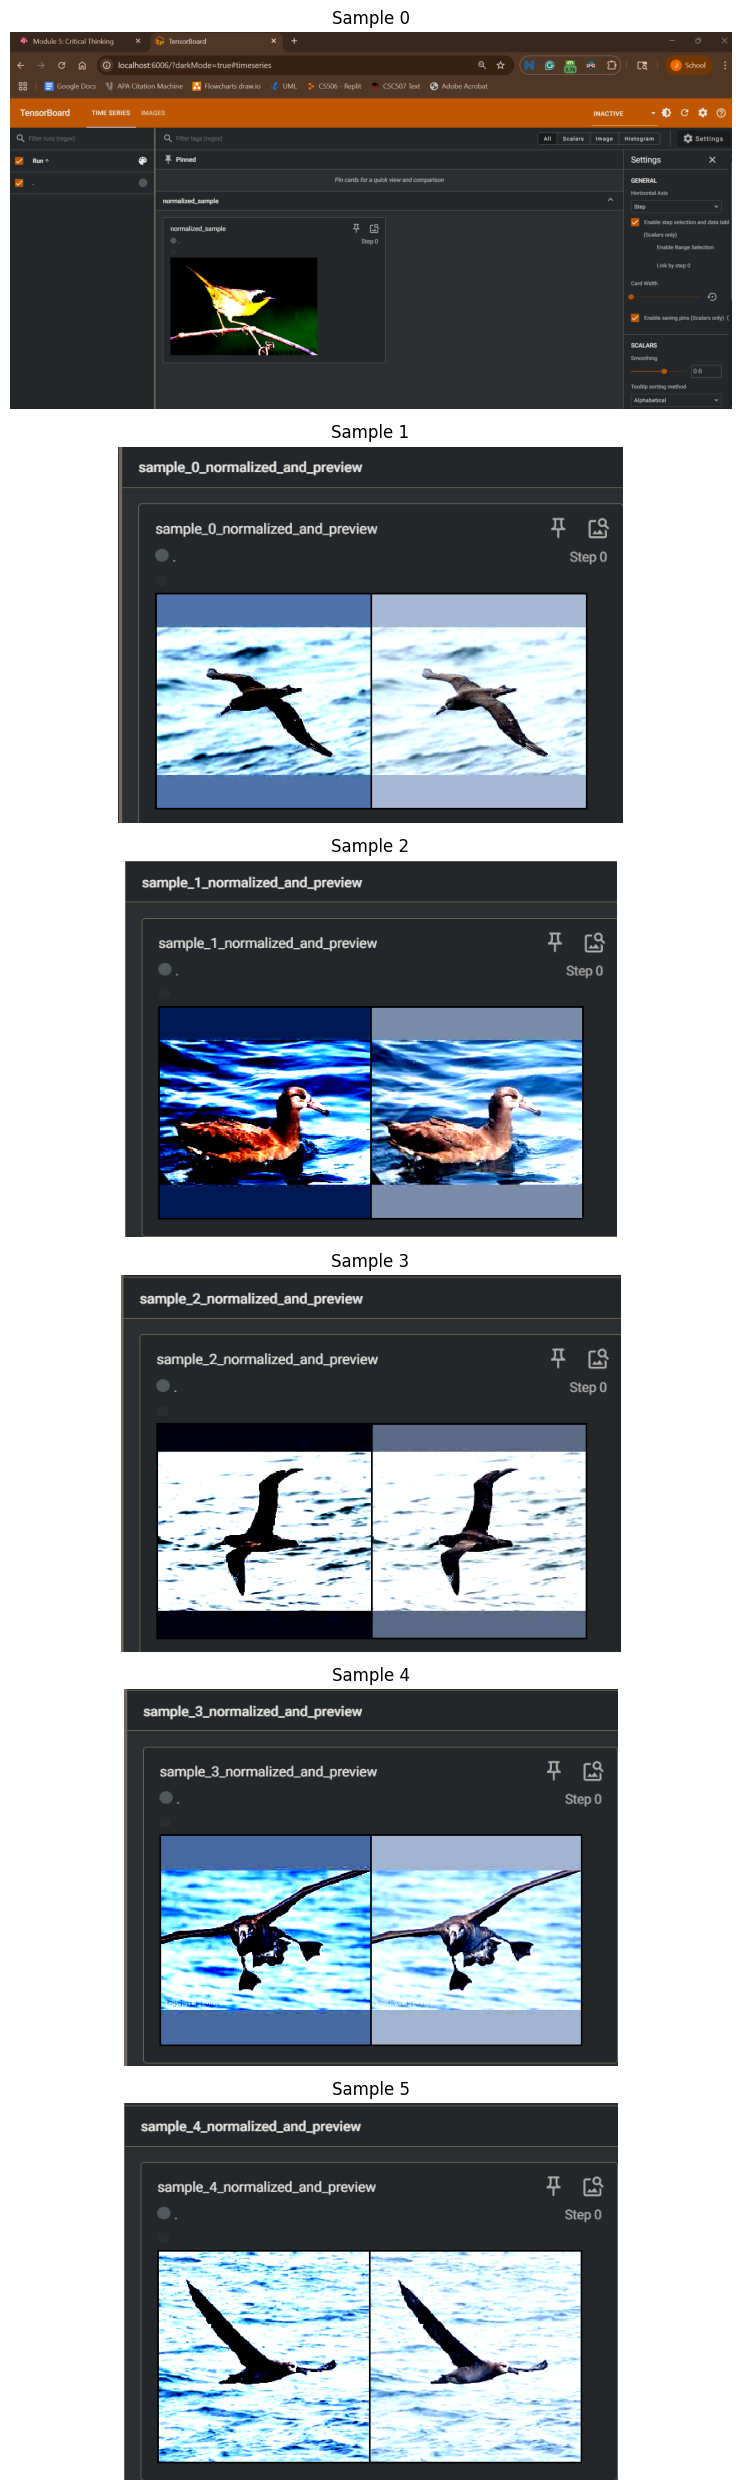

In [50]:
#Since we can't call up TensorBoard directly in a Jupyter notebook, the next best option is to capture screenshots and then display them as a PyPlot

screenshot_paths = [
    "images/Image_W5CT_NormalizedTensorboard_FirstExample.png",
    "images/Image_W5CT_NormalizedTensorboard_0.png",
    "images/Image_W5CT_NormalizedTensorboard_1.png",
    "images/Image_W5CT_NormalizedTensorboard_2.png",
    "images/Image_W5CT_NormalizedTensorboard_3.png",
    "images/Image_W5CT_NormalizedTensorboard_4.png",
]


fig, axes = plt.subplots(len(screenshot_paths), 1, figsize=(10, 25))
for index, (ax, path) in enumerate(zip(axes, screenshot_paths)):
    img = Image.open(path)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"Sample {index}")

plt.tight_layout()
plt.show()

#This was my first time using TensorBoard, it was a bit of a learning curve. Sample 0 is what had me questioning my sanity because the gray padding I'd worked so hard to develop was completely gone when I was able to get the normalized pixel data visible on Tensorboard. Understanding that data that fell outside the standard [0, 1] display range was being clipped during visualization made it seem like the padding had disappeared completely. Understanding that behavior helped me to correctly interpret what I was seeing and ultimately verify that the preprocessing was indeed working as intended

In [51]:
#Same process as above where we applied the resizing augmentation and moved the files to the Augmented folder, now we'll do the same thing but will make a separate folder to hold the tensors. Once these files already exist there is no need to overwrite them each time the script runs, and we can skip this cell entirely if the .pt files are already present in the target directory. This helps avoid unnecessary recomputation and prevents memory issues when working with large datasets in modern IDEs that like to save a lot of data in memory

source = Path("data/W5CT_BirdSpeciesData_Resized/images")
destination = Path("data/W5CT_BirdSpeciesData_NormalizedTensors")

to_tensor = transforms.ToTensor()
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
#(PyTorch Forums, 2023)

#This if statement is a guard clause, that ensures that the normalization loop only needs to run once. It prevents reprocessing and protects against memory overuse. "If the destination folder doesn't exist, or if there are no .pt files inside it, then run the normalization loop"
if not destination.exists() or not any(destination.rglob("*.pt")):

    #This is the main normalization loop that iterates through all .jpg images in the augmented folder and saves the result as a .pt tensor file in the tensor folder.
    for file in source.rglob("*.jpg"):

        #Takes the image path, strips off the base directory to get the relative subfolder, and replace the jpg extension with .pt to save the tensor in the same file structure as the augmented folder
        relative_path = file.relative_to(source).with_suffix(".pt")

        #Create the path to the destination tensor file by combining the destination folder with the relative subpath derived from the original image
        destination_file = destination / relative_path

        #Make sure the folder exists where this tensor will be saved including any parent directories
        destination_file.parent.mkdir(parents=True, exist_ok=True)

        #Open the image file using the Pillow library and ensure it is converted to RGB format if not already (should already be RGB)
        image = Image.open(file).convert("RGB")

        #Transform the image from a PIL image to a PyTorch tensor for normalization
        tensor = to_tensor(image)

        #Standardize the image tensor so that each color channel is zero-centered and scaled according to the mean and standard deviation used in ImageNet pretraining. This should ensure compatibility with models expecting input normalized to those specific distributions
        normalized_tensor = normalize(tensor)

        #Save the normalized tensor to disk as a .pt file so that it can be loaded later without having to re-run the whole pipeline
        torch.save(normalized_tensor, destination_file)


else:
    print("Normalized .pt files already exist — skipping.")


In [52]:
#At this point, my IDE PyCharm let me know I was running into low memory issues, this surprised me because I had assumed that saving the normalized tensors to disk would prevent any major memory buildup, however after looking at the heap dump, it became clear that Jupyter was holding onto a large amount of memory, mostly through cell outputs, background indexing, and UI elements associated with rendering TensorBoard previews. Even though the actual image data was being written to disk as .pt files, PyCharm was still storing the full memory representation of each intermediate computation, preview, and log entry. To remedy this I restarted the kernel and added a guard clause so that the tensor files would not need to be overwritten. A better solution would be to proactively manage memory during long-running sessions by explicitly deleting large intermediate variables with del, invoking early garbage collection using gc.collect(), and avoiding heavy visualizations in TensorBoard unless necessary. Clearing cell outputs and periodically restarting the kernel can help prevent memory leaks in Jupyter when running within PyCharm, where UI state and logging buffers tend to accumulate.

In [53]:
#Ailurophile. (2020). 200 bird species with 11,788 images [Data set]. Kaggle.
#https://www.kaggle.com/datasets/veeralakrishna/200-bird-species-with-11788-images

#GeeksforGeeks. (2025). Python random module. GeeksforGeeks.
#https://www.geeksforgeeks.org/python/python-random-module/

#Grimoire. (2025, June 15). AI conversation about creating PyPlots to visualize image data. OpenAI.
#https://chat.openai.com

#Gruppetta, S. (2025, January 8). Image processing with the Python Pillow library. Real Python.
#https://realpython.com/image-processing-with-the-python-pillow-library/

#Hjelle, G. A. (2025, January 11). Python’s pathlib module: Taming the file system. Real Python.
#https://realpython.com/python-pathlib/

#Hunter, J., Dale, D., Firing, E., Droettboom, M., & The Matplotlib Development Team. (2025). Pyplot tutorial. The Matplotlib Project.
#https://matplotlib.org/stable/tutorials/pyplot.html

#Karpinsky, A. (2022, September 19). The fastest production-ready image resize. Part 0. Uploadcare.
#https://uploadcare.com/blog/the-fastest-image-resize/

#Kashyap, P. (2024, December 2). Image normalization in PyTorch: From tensor conversion to scaling. Medium.
#https://medium.com/@piyushkashyap045/image-normalization-in-pytorch-from-tensor-conversion-to-scaling-3951b6337bc8

#Nelson, J. (2020, February 21). Why and how to implement random crop data augmentation. Roboflow.
#https://blog.roboflow.com/why-and-how-to-implement-random-crop-data-augmentation/

#Pillow Documentation. (2011). ImageOps module. Pillow (PIL Fork) Documentation.
#https://pillow.readthedocs.io/en/stable/reference/ImageOps.html

#Python Documentation. (n.d. -a). pathlib — Object-oriented filesystem paths.
#https://docs.python.org/3/library/pathlib.html

#Python Documentation. (n.d. -b). shutil — High-level file operations. Python 3.12 Documentation.
#https://docs.python.org/3/library/shutil.html

#PyTorch Documentation. (n.d. -a). Transforms v0.15.
#https://docs.pytorch.org/vision/0.15/transforms.html

#PyTorch Documentation. (n.d. -b). torch.utils.tensorboard: PyTorch TensorBoard support.
#https://pytorch.org/docs/stable/tensorboard.html

#PyTorch Documentation. (n.d. -c). TorchVision models documentation.
#https://docs.pytorch.org/vision/0.8/models.html

#PyTorch Documentation. (n.d. -d). torchvision.transforms.ColorJitter.
#https://docs.pytorch.org/vision/main/generated/torchvision.transforms.ColorJitter.html

#PyTorch Forums. (2023, September 14). Why image datasets need normalizing with means and stds specified like in transforms.
#https://discuss.pytorch.org/t/why-image-datasets-need-normalizing-with-means-and-stds-specified-like-in-transforms-normalize-mean-0-485-0-456-0-406-std-0-229-0-224-0-225/187818

#Selvaraju, R. R., Cogswell, M., Das, A., Vedantam, R., Parikh, D., & Batra, D. (2019). Grad-CAM: Visual explanations from deep networks via gradient-based localization. arXiv.
#https://arxiv.org/pdf/1610.02391

#Stashevsky, A. (2023, April 25). On‑the‑fly augmentation with PyTorch, Geometric, and Lightning: What tutorials don’t teach.
#https://alecstashevsky.com/post/on-the-fly-augmentation-with-pytorch-geometric-and-lightning-what-tutorials-dont-teach/